In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib as mpl
import joblib

# 1 Carga de datos

In [22]:
df=pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv', sep=';')

In [23]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## Codificamos la columna  Quality 

In [24]:
df['quality']=pd.cut(df['quality'],bins=[3,4,6,8],labels=[0,1,2], include_lowest=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,1


# 2. Entrenamiento del modelo KNN

## Train test split

In [25]:
x = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(x , y, test_size=0.2, random_state=42)

# 3 Evaluación de rendimiento

## Escalamos y modelamos

In [26]:
yhat_no_scaling = KNeighborsClassifier(n_neighbors=3, algorithm='brute').fit(X_train, y_train).predict(X_test)


sc_standard = StandardScaler().fit(X_train)
yhat_standard = KNeighborsClassifier(n_neighbors=3, algorithm='brute').fit(sc_standard.transform(X_train), y_train).predict(sc_standard.transform(X_test))

sc_norm = MinMaxScaler().fit(X_train)
yhat_norm = KNeighborsClassifier(n_neighbors=3, algorithm='brute').fit(sc_norm.transform(X_train), y_train).predict(sc_norm.transform(X_test))

Reporte para los datos sin escalar:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.85      0.91      0.88       262
           2       0.48      0.34      0.40        47

    accuracy                           0.79       320
   macro avg       0.44      0.42      0.43       320
weighted avg       0.77      0.79      0.78       320



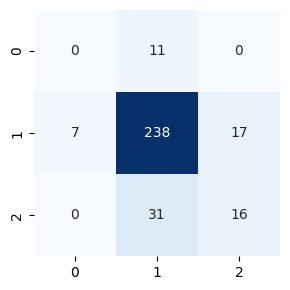

Accuracy: 0.79375
Reporte para los datos estandarizados:
              precision    recall  f1-score   support

           0       0.33      0.09      0.14        11
           1       0.87      0.94      0.90       262
           2       0.59      0.43      0.49        47

    accuracy                           0.83       320
   macro avg       0.60      0.49      0.51       320
weighted avg       0.81      0.83      0.82       320



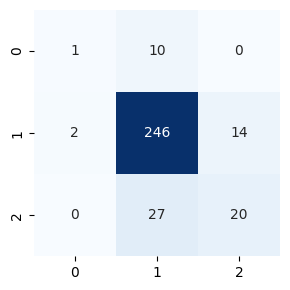

Accuracy: 0.834375
Reporte para los datos normalizados:
              precision    recall  f1-score   support

           0       0.50      0.18      0.27        11
           1       0.89      0.95      0.92       262
           2       0.68      0.53      0.60        47

    accuracy                           0.86       320
   macro avg       0.69      0.55      0.59       320
weighted avg       0.85      0.86      0.85       320



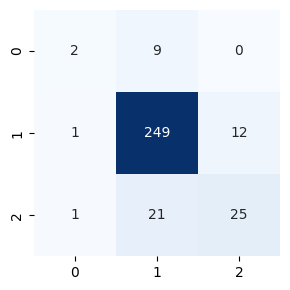

Accuracy: 0.8625


In [27]:
print(f'Reporte para los datos sin escalar:\n{classification_report(y_test, yhat_no_scaling)}')
vinos_cm = confusion_matrix(y_test, yhat_no_scaling)
cm_df = pd.DataFrame(vinos_cm)
plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False, cmap="Blues")
plt.tight_layout()
plt.show()
print("Accuracy:", accuracy_score(y_test, yhat_no_scaling))

print(f'Reporte para los datos estandarizados:\n{classification_report(y_test, yhat_standard)}')
vinos_cm = confusion_matrix(y_test, yhat_standard)
cm_df = pd.DataFrame(vinos_cm)
plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False, cmap="Blues")
plt.tight_layout()
plt.show()
print("Accuracy:", accuracy_score(y_test, yhat_standard))

print(f'Reporte para los datos normalizados:\n{classification_report(y_test, yhat_norm)}')
vinos_cm = confusion_matrix(y_test, yhat_norm)
cm_df = pd.DataFrame(vinos_cm)
plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False, cmap="Blues")
plt.tight_layout()
plt.show()
print("Accuracy:", accuracy_score(y_test, yhat_norm))


# 4. Optimización de k

In [28]:

# Escalamos los datos
sc_norm = MinMaxScaler().fit(X_train)
X_train_norm = sc_norm.transform(X_train)
X_test_norm = sc_norm.transform(X_test)

accuracies = []

# hacemos un bucle para probar diferentes valores de K
for k in range(1, 21):   
    knn = KNeighborsClassifier(n_neighbors=k, algorithm='brute')
    knn.fit(X_train_norm, y_train)
    yhat = knn.predict(X_test_norm)

    acc = accuracy_score(y_test, yhat)
    accuracies.append(acc)

    print(f"K = {k}: Accuracy = {acc:.4f}")

# Mejor K
best_k = accuracies.index(max(accuracies)) + 1
print(f"\n El mejor K es: {best_k} con accuracy: {max(accuracies):.4f}")

K = 1: Accuracy = 0.8344
K = 2: Accuracy = 0.8281
K = 3: Accuracy = 0.8625
K = 4: Accuracy = 0.8438
K = 5: Accuracy = 0.8375
K = 6: Accuracy = 0.8562
K = 7: Accuracy = 0.8469
K = 8: Accuracy = 0.8500
K = 9: Accuracy = 0.8500
K = 10: Accuracy = 0.8500
K = 11: Accuracy = 0.8500
K = 12: Accuracy = 0.8438
K = 13: Accuracy = 0.8438
K = 14: Accuracy = 0.8406


K = 15: Accuracy = 0.8406
K = 16: Accuracy = 0.8281
K = 17: Accuracy = 0.8281
K = 18: Accuracy = 0.8219
K = 19: Accuracy = 0.8219
K = 20: Accuracy = 0.8156

 El mejor K es: 3 con accuracy: 0.8625


# Graficamos

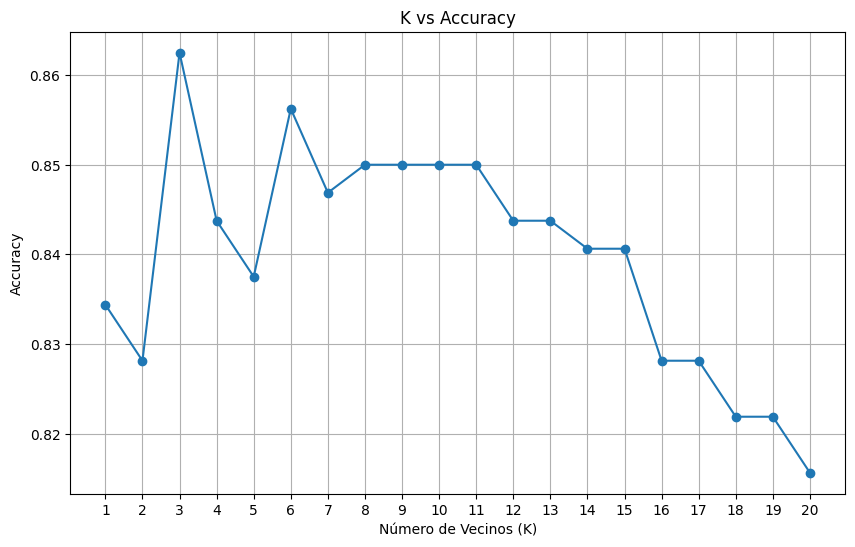

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracies, marker='o')
plt.title('K vs Accuracy')
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.grid()
plt.show()

# Guardamos el modelo Normalizado que fue el mejor y K=3 (best_k)

In [42]:
scaler = MinMaxScaler().fit(X_train)

knn = KNeighborsClassifier(n_neighbors=best_k, algorithm='brute')
knn.fit(scaler.transform(X_train), y_train)

joblib.dump(scaler, "scaler.pkl")
joblib.dump(knn, "knn_model.pkl")

['knn_model.pkl']

In [44]:
# cargamos el modelo
scaler = joblib.load("scaler.pkl")
model = joblib.load("knn_model.pkl")

# Predeccimos los nuevos datos

In [49]:
quality_map = {
    0: "Calidad baja",
    1: "Calidad media",
    2: "Calidad alta"}

In [50]:
new_data=[[7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]]
nuevo_scaled = scaler.transform(new_data)

pred = knn.predict(nuevo_scaled)
pred_label = quality_map[pred[0]]
print(pred_label)

Calidad media


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
